## Looking for patterns in the UK flora

There is a long history of botanical recording in Britain, with detailed records dating back at least 330 years, with the earliest systematic records dating back to Sir John Ray in the 1670s.  The **UK Flora** dataset comprises data from three separate sources on the plants of the UK.

As part of the Darwin Tree of Life program (https://www.darwintreeoflife.org/) a database was assembled which put together data from the most recent reference flora of Britain and Ireland, with taxon names linked to unique Kew taxon identifiers and DNA barcode data. It covers 3,227 species and 26 traits includes genome sizes, chromosome numbers and life strategy and life-form assessments, along with some data on functional traits, species distribution metrics, hybrid propensity, associated biomes, realized niche description, native status and geographic origin of alien species:

Henniges, M.C., Powell, R.F., Mian, S. et al. A taxonomic, genetic and ecological data resource for the vascular plants of Britain and Ireland. Sci Data 9, 1 (2022). https://doi.org/10.1038/s41597-021-01104-5

The Ecological Flora of the British Isles is a database constructed from a wide variety of sources by Dr Helen Peat and Professor Alastair Fitter at the University of York, with financial support from the British Ecological Society and the Natural Environment Research Council. It consists of data on 3842 species of higher plants that occur in the British Isles (of which some 2000 species including all the British Natives and many common introductions have ecological traits entered), together with the bibliography of sources. The version you will use has been produced by Dr Henry Ford.

The data comprises information on taxonomy (family, genus, specific name, authority, and vernacular name, together with common synonyms), a suite of over 130 ecological and morphological characteristics, vice-county distribution in Britain, European distribution by country, mycorrhizal associations, associated phytophagous insects and fungi. The data are obtained from the literature and the coverage varies greatly between species. The data set is therefore incomplete.

http://ecoflora.org.uk/

The global leaf traits database collects global databases related to plants and is very rich (https://www.try-db.org/TryWeb/Home.php).  I have included a selection of it here in this combined data base.

Detail on the traits are here:  
        for the UK Flora explorer  
    https://github.com/RBGKew/BIFloraExplorer  
        for the Ecological flora:  
    http://ecoflora.org.uk/help/help.php  
        and, for the TRY database here:  
    https://www.try-db.org/TryWeb/Home.php  

##### Setting up the basic analysis environment

In [1]:
# Analysis modules
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import statsmodels.api as sm
np.set_printoptions(precision=5, suppress=True)  # suppress scientific floatation 
sns.set(color_codes=True)
%matplotlib inline
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

Have a look at the data file

Open up the files

In [2]:
! head UK_Flora_data.csv

Binomial,authors,order,family,genus,species,WCVP_URL,POWO_URL,IPNI_URL,accepted_WCVP_URL,StaceIV_nativity,Atlas_nativity_viaALIENATT_PLANTATT,Stace_Crawley_nativity_aliens,SLA,LDMC,seed_mass,leaf_area,mean_veg_height,max_veg_height,L_PLANTATT,F_PLANTATT,R_PLANTATT,N_PLANTATT,S_PLANTATT,L_Doring,F_Doring,R_Doring,N_Doring,S_Doring,T_Doring,ECPE_CSR,predicted_CSR,growth_form,succulence,life_form,biome,origin,TDWG_level_1_code,GB_Man_hectads_post2000,Ire_hectads_post2000,CI_hectads_post2000,GB_Man_hectads_1987_1999,Ire_hectads_1987_1999,CI_hectads_1987_1999,GB_Man_hectads_2000_2009,Ire_hectads_2000_2009,CI_hectads_2000_2009,GB_Man_hectads_2010_2019,Ire_hectads_2010_2019,CI_hectads_2010_2019,hybrid_propensity,scaled_hybrid_propensity,BOLD_link1,BOLD_link2,BOLD_link3,GS_1C_pg,GS_2C_pg,GS_1C_Mbp,GS_2C_Mbp,from_BI_material,data_source,sporophytic_chromosome_number,infraspecific_variation_chrom_number,other_reported_sporophytic_chromosome_number,source_of_other_chrom_num,AccSpeciesName,Actual 

Read the main dataset in.  You may have to use low_memory=False as it's large

In [69]:
flora_df = pd.read_csv('UK_Flora_data.csv', low_memory=False)

In [70]:
flora_df.head(3)

,Binomial,authors,order,family,genus,species,WCVP_URL,POWO_URL,IPNI_URL,accepted_WCVP_URL,StaceIV_nativity,Atlas_nativity_viaALIENATT_PLANTATT,Stace_Crawley_nativity_aliens,SLA,LDMC,seed_mass,leaf_area,mean_veg_height,max_veg_height,L_PLANTATT,F_PLANTATT,R_PLANTATT,N_PLANTATT,S_PLANTATT,L_Doring,F_Doring,R_Doring,N_Doring,S_Doring,T_Doring,ECPE_CSR,predicted_CSR,growth_form,succulence,life_form,biome,origin,TDWG_level_1_code,GB_Man_hectads_post2000,Ire_hectads_post2000,CI_hectads_post2000,GB_Man_hectads_1987_1999,Ire_hectads_1987_1999,CI_hectads_1987_1999,GB_Man_hectads_2000_2009,Ire_hectads_2000_2009,CI_hectads_2000_2009,GB_Man_hectads_2010_2019,Ire_hectads_2010_2019,CI_hectads_2010_2019,hybrid_propensity,scaled_hybrid_propensity,BOLD_link1,BOLD_link2,BOLD_link3,GS_1C_pg,GS_2C_pg,GS_1C_Mbp,GS_2C_Mbp,from_BI_material,data_source,sporophytic_chromosome_number,infraspecific_variation_chrom_number,other_reported_sporophytic_chromosome_number,source_of_other_chrom_num,AccSpeciesName,Actual EvapoTranspiration,After-ripening requirement,Altitude,Altitude (maximum recorded),Altitude (minimum recorded),Altitude (typical minimum),Annual precipitation,Annual seed dispersal,Appendages on dispersal unit,Average annual relative humidity,Average number of ground frost days per year (sum) (FRS),British distribution (post 1949 records),Carnivory,Change Index,Chromosome cDNA content,Chromosome number,Chromosome ploidy,Cleistogamy,Clonality,Cloud cover,"Comments, notes, methods","Dicliny (monoeceous, dioecious, hermaphrodite)",Dispersal syndrome (agent),Dispersal unit (dispersule / diaspore) length,EW Index,Ecosystem rooting depth,Ellenberg indicator value: Light,Ellenberg indicator value: Moisture,Ellenberg indicator value: Salt tolerance,Ellenberg indicator value: nitrogen,Ellenberg indicator value: pH (reaction),End of flowering,Epoch,Exposure,Fern and moss spore width (diameter),Fertilization,Fine root diameter,First historical record: 1. date,First historical record: 2. site,Flower pollen ovule ratio,Flowering period: peak month,Fraction of absorbed photosynthetic active radiation (FAPAR) of the site,GPP of the site,Genera growth form,Germination requirements 1. chilling,Germination requirements 2. light,Germination requirements 3. temperature fluctuation,Germination type,Habitat / plot description,Heteromorphy,Heterophylly,Identifier within contributed dataset (ID),Inbreeding,Incompatibility systems,Intensity of mycorrhizal infection,January mean temperature,July mean temperature,Latitude,Leaf Relative water content (water content / water content at saturation),Leaf Water content (molar) per leaf dry mass (WCd),Leaf Water content saturating (molar) (WCs),Leaf Water content total (molar) (WCt),Leaf area index of the site (LAI),Leaf area: in case of compound leaves undefined if leaf or leaflet; undefined if petiole and rhachis in- or excluded,Leaf carbon content per area,Leaf carbon content per dry mass,Leaf carbon/nitrogen (C/N) ratio,Leaf carotenoid content per dry mass,Leaf chlorophyll a content per dry mass,Leaf chlorophyll a+b content per area,Leaf chlorophyll a/b ratio,Leaf chlorophyll b content per dry mass,Leaf chlorophyll content (a+b) per dry mass,Leaf compoundness,Leaf dry matter content per leaf water-saturated mass (LDMC),Leaf lamina thickness,"Leaf lifespan (longevity, retention time, LL)",Leaf nitrogen content per area (Narea),Leaf nitrogen content per dry mass (Nmass),Leaf petiole length,Leaf phenology type,Leaf phosphorus content per area (Parea),Leaf phosphorus content per dry mass (Pmass),Leaf position,Leaf respiration per area at leaf temperature,Leaf respiration per dry mass,Leaf shape: 2. outline,Leaf shape: 3. pointed/round,Leaf shape: 4. length versus breadth,Leaf shape: 5. leaf base,Leaf shape: 6. leaf petiole type,Leaf thickness,Leaf tissue density,Leaf transpiration (molar) per dry mass,Leaf transpiration rate per dry mass (daytime),Leaf water content per leaf dry mass,"Leaf water content per leaf water-saturated 

What shape is the dataframe?

What's in the dataframe?

In [8]:
flora_df.shape

(3302, 315)

3302 data lines, 315 traits!

How much missing data is there for each trait? Use df.isna().sum()

In [10]:
flora_df.isna().sum()

Binomial                                                                                                                                             0
authors                                                                                                                                              0
order                                                                                                                                               12
family                                                                                                                                               0
genus                                                                                                                                                0
species                                                                                                                                              0
WCVP_URL                                                                                      

Bear this in mind when planning hypothesis.  It is difficult to test a hypothesis if you have very little data, and traits with very little data are also likely to be skewed.

The amount of data here is quite overwhelming.  Take some time to look at the traits included.  I have made a summary of the traits from the Darwin Tree of Life data and the Ecological Flora (Flora_Trait_list.csv).  The TRY database has excellent detail here: https://www.try-db.org/TryWeb/Home.php).
For a few traits the exact definations/detail are missing - you will have to search the literature.  In some cases the exact name in the 'definations' does not match that in the database - be flexible in searching!

Find what data there is on the *Poa* genus.  

    Use .isin

In [33]:
flora_df[flora_df['genus'].isin(['Poa'])]

,Binomial,authors,order,family,genus,species,WCVP_URL,POWO_URL,IPNI_URL,accepted_WCVP_URL,StaceIV_nativity,Atlas_nativity_viaALIENATT_PLANTATT,Stace_Crawley_nativity_aliens,SLA,LDMC,seed_mass,leaf_area,mean_veg_height,max_veg_height,L_PLANTATT,F_PLANTATT,R_PLANTATT,N_PLANTATT,S_PLANTATT,L_Doring,F_Doring,R_Doring,N_Doring,S_Doring,T_Doring,ECPE_CSR,predicted_CSR,growth_form,succulence,life_form,biome,origin,TDWG_level_1_code,GB_Man_hectads_post2000,Ire_hectads_post2000,CI_hectads_post2000,GB_Man_hectads_1987_1999,Ire_hectads_1987_1999,CI_hectads_1987_1999,GB_Man_hectads_2000_2009,Ire_hectads_2000_2009,CI_hectads_2000_2009,GB_Man_hectads_2010_2019,Ire_hectads_2010_2019,CI_hectads_2010_2019,hybrid_propensity,scaled_hybrid_propensity,BOLD_link1,BOLD_link2,BOLD_link3,GS_1C_pg,GS_2C_pg,GS_1C_Mbp,GS_2C_Mbp,from_BI_material,data_source,sporophytic_chromosome_number,infraspecific_variation_chrom_number,other_reported_sporophytic_chromosome_number,source_of_other_chrom_num,AccSpeciesName,Actual EvapoTranspiration,After-ripening requirement,Altitude,Altitude (maximum recorded),Altitude (minimum recorded),Altitude (typical minimum),Annual precipitation,Annual seed dispersal,Appendages on dispersal unit,Average annual relative humidity,Average number of ground frost days per year (sum) (FRS),British distribution (post 1949 records),Carnivory,Change Index,Chromosome cDNA content,Chromosome number,Chromosome ploidy,Cleistogamy,Clonality,Cloud cover,"Comments, notes, methods","Dicliny (monoeceous, dioecious, hermaphrodite)",Dispersal syndrome (agent),Dispersal unit (dispersule / diaspore) length,EW Index,Ecosystem rooting depth,Ellenberg indicator value: Light,Ellenberg indicator value: Moisture,Ellenberg indicator value: Salt tolerance,Ellenberg indicator value: nitrogen,Ellenberg indicator value: pH (reaction),End of flowering,Epoch,Exposure,Fern and moss spore width (diameter),Fertilization,Fine root diameter,First historical record: 1. date,First historical record: 2. site,Flower pollen ovule ratio,Flowering period: peak month,Fraction of absorbed photosynthetic active radiation (FAPAR) of the site,GPP of the site,Genera growth form,Germination requirements 1. chilling,Germination requirements 2. light,Germination requirements 3. temperature fluctuation,Germination type,Habitat / plot description,Heteromorphy,Heterophylly,Identifier within contributed dataset (ID),Inbreeding,Incompatibility systems,Intensity of mycorrhizal infection,January mean temperature,July mean temperature,Latitude,Leaf Relative water content (water content / water content at saturation),Leaf Water content (molar) per leaf dry mass (WCd),Leaf Water content saturating (molar) (WCs),Leaf Water content total (molar) (WCt),Leaf area index of the site (LAI),Leaf area: in case of compound leaves undefined if leaf or leaflet; undefined if petiole and rhachis in- or excluded,Leaf carbon content per area,Leaf carbon content per dry mass,Leaf carbon/nitrogen (C/N) ratio,Leaf carotenoid content per dry mass,Leaf chlorophyll a content per dry mass,Leaf chlorophyll a+b content per area,Leaf chlorophyll a/b ratio,Leaf chlorophyll b content per dry mass,Leaf chlorophyll content (a+b) per dry mass,Leaf compoundness,Leaf dry matter content per leaf water-saturated mass (LDMC),Leaf lamina thickness,"Leaf lifespan (longevity, retention time, LL)",Leaf nitrogen content per area (Narea),Leaf nitrogen content per dry mass (Nmass),Leaf petiole length,Leaf phenology type,Leaf phosphorus content per area (Parea),Leaf phosphorus content per dry mass (Pmass),Leaf position,Leaf respiration per area at leaf temperature,Leaf respiration per dry mass,Leaf shape: 2. outline,Leaf shape: 3. pointed/round,Leaf shape: 4. length versus breadth,Leaf shape: 5. leaf base,Leaf shape: 6. leaf petiole type,Leaf thickness,Leaf tissue density,Leaf transpiration (molar) per dry mass,Leaf transpiration rate per dry mass (daytime),Leaf water content per leaf dry mass,"Leaf water content per leaf water-saturated 

Find the data on the species *Scutellaria minor*.  Oddly the names in the column 'Binomial do not have their genus starting with a captial.

In [36]:
flora_df[flora_df['Binomial'].isin(['scutellaria minor'])]

,Binomial,authors,order,family,genus,species,WCVP_URL,POWO_URL,IPNI_URL,accepted_WCVP_URL,StaceIV_nativity,Atlas_nativity_viaALIENATT_PLANTATT,Stace_Crawley_nativity_aliens,SLA,LDMC,seed_mass,leaf_area,mean_veg_height,max_veg_height,L_PLANTATT,F_PLANTATT,R_PLANTATT,N_PLANTATT,S_PLANTATT,L_Doring,F_Doring,R_Doring,N_Doring,S_Doring,T_Doring,ECPE_CSR,predicted_CSR,growth_form,succulence,life_form,biome,origin,TDWG_level_1_code,GB_Man_hectads_post2000,Ire_hectads_post2000,CI_hectads_post2000,GB_Man_hectads_1987_1999,Ire_hectads_1987_1999,CI_hectads_1987_1999,GB_Man_hectads_2000_2009,Ire_hectads_2000_2009,CI_hectads_2000_2009,GB_Man_hectads_2010_2019,Ire_hectads_2010_2019,CI_hectads_2010_2019,hybrid_propensity,scaled_hybrid_propensity,BOLD_link1,BOLD_link2,BOLD_link3,GS_1C_pg,GS_2C_pg,GS_1C_Mbp,GS_2C_Mbp,from_BI_material,data_source,sporophytic_chromosome_number,infraspecific_variation_chrom_number,other_reported_sporophytic_chromosome_number,source_of_other_chrom_num,AccSpeciesName,Actual EvapoTranspiration,After-ripening requirement,Altitude,Altitude (maximum recorded),Altitude (minimum recorded),Altitude (typical minimum),Annual precipitation,Annual seed dispersal,Appendages on dispersal unit,Average annual relative humidity,Average number of ground frost days per year (sum) (FRS),British distribution (post 1949 records),Carnivory,Change Index,Chromosome cDNA content,Chromosome number,Chromosome ploidy,Cleistogamy,Clonality,Cloud cover,"Comments, notes, methods","Dicliny (monoeceous, dioecious, hermaphrodite)",Dispersal syndrome (agent),Dispersal unit (dispersule / diaspore) length,EW Index,Ecosystem rooting depth,Ellenberg indicator value: Light,Ellenberg indicator value: Moisture,Ellenberg indicator value: Salt tolerance,Ellenberg indicator value: nitrogen,Ellenberg indicator value: pH (reaction),End of flowering,Epoch,Exposure,Fern and moss spore width (diameter),Fertilization,Fine root diameter,First historical record: 1. date,First historical record: 2. site,Flower pollen ovule ratio,Flowering period: peak month,Fraction of absorbed photosynthetic active radiation (FAPAR) of the site,GPP of the site,Genera growth form,Germination requirements 1. chilling,Germination requirements 2. light,Germination requirements 3. temperature fluctuation,Germination type,Habitat / plot description,Heteromorphy,Heterophylly,Identifier within contributed dataset (ID),Inbreeding,Incompatibility systems,Intensity of mycorrhizal infection,January mean temperature,July mean temperature,Latitude,Leaf Relative water content (water content / water content at saturation),Leaf Water content (molar) per leaf dry mass (WCd),Leaf Water content saturating (molar) (WCs),Leaf Water content total (molar) (WCt),Leaf area index of the site (LAI),Leaf area: in case of compound leaves undefined if leaf or leaflet; undefined if petiole and rhachis in- or excluded,Leaf carbon content per area,Leaf carbon content per dry mass,Leaf carbon/nitrogen (C/N) ratio,Leaf carotenoid content per dry mass,Leaf chlorophyll a content per dry mass,Leaf chlorophyll a+b content per area,Leaf chlorophyll a/b ratio,Leaf chlorophyll b content per dry mass,Leaf chlorophyll content (a+b) per dry mass,Leaf compoundness,Leaf dry matter content per leaf water-saturated mass (LDMC),Leaf lamina thickness,"Leaf lifespan (longevity, retention time, LL)",Leaf nitrogen content per area (Narea),Leaf nitrogen content per dry mass (Nmass),Leaf petiole length,Leaf phenology type,Leaf phosphorus content per area (Parea),Leaf phosphorus content per dry mass (Pmass),Leaf position,Leaf respiration per area at leaf temperature,Leaf respiration per dry mass,Leaf shape: 2. outline,Leaf shape: 3. pointed/round,Leaf shape: 4. length versus breadth,Leaf shape: 5. leaf base,Leaf shape: 6. leaf petiole type,Leaf thickness,Leaf tissue density,Leaf transpiration (molar) per dry mass,Leaf transpiration rate per dry mass (daytime),Leaf water content per leaf dry mass,"Leaf water content per leaf water-saturated 

How many species from the Rose family are in the data set?

In [41]:
flora_df[flora_df['family'].isin(['Rosaceae'])].shape

(322, 315)

In [ ]:
Have a look at the traits.
    Is date of flowering realated to length of growing season?

<Axes: xlabel='Length of growing season (LGP)', ylabel='max_veg_height'>

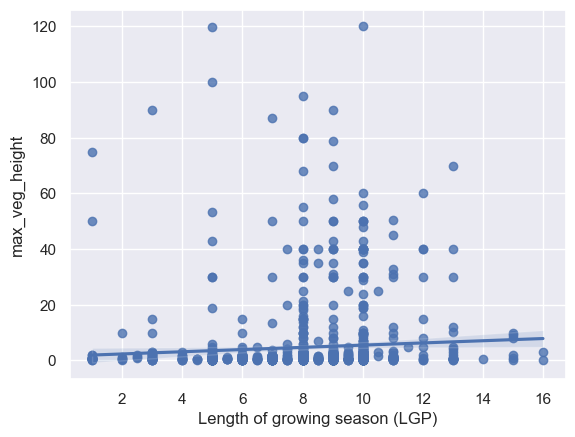

In [42]:
sns.regplot(data=flora_df, x="Length of growing season (LGP)", y="max_veg_height")

What are the units here?  cm and weeks.

In [ ]:
longevity of stems (years)

<Axes: xlabel='Stem longevity', ylabel='max_veg_height'>

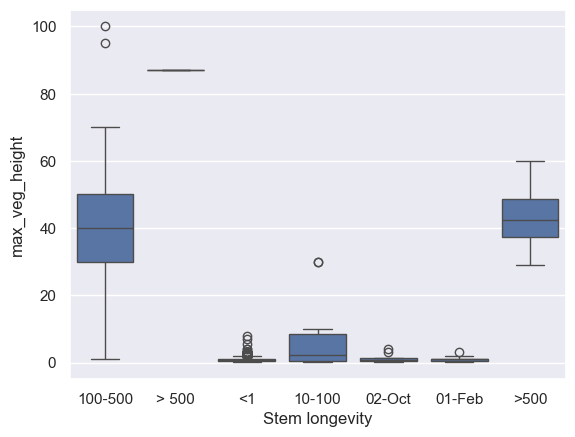

In [45]:
sns.boxplot(data=flora_df, x="Stem longevity", y="max_veg_height")

It's clear that the data has gone through excel - 02 Oct and 01-Feb should be 1-2 and 2-10 years

Several of traits are very closely correalated - for example there are 3 measures of Light requirement: 'L_PLANTATT', 'L_Doring', 'Ellenberg indicator value: Light'.
Subset the dataframe to just these columns and use df.corr to see how correalted they are.

In [51]:
light_df = flora_df[['L_PLANTATT', 'L_Doring', 'Ellenberg indicator value: Light']]
corr = light_df.corr()

In [53]:
corr

,L_PLANTATT,L_Doring,Ellenberg indicator value: Light
L_PLANTATT,1.000000,0.916760,0.997068
L_Doring,0.916760,1.000000,0.924286
Ellenberg indicator value: Light,0.997068,0.924286,1.000000


For a quick look at correlations across the dataset let's keep only columns with at least 1000 records, select the numeric traits and plot a heat map.

    df.dropna(thresh = 1000, axis = 1)
    df.select_dtypes(include=np.number)

In [75]:
rich_df = flora_df.dropna(thresh = 1000, axis = 1)

In [76]:
rich_df.shape

(3302, 175)

In [78]:
rich_df.select_dtypes(include=np.number).columns.tolist()

['SLA',
 'LDMC',
 'seed_mass',
 'leaf_area',
 'mean_veg_height',
 'max_veg_height',
 'L_PLANTATT',
 'F_PLANTATT',
 'R_PLANTATT',
 'N_PLANTATT',
 'S_PLANTATT',
 'L_Doring',
 'F_Doring',
 'R_Doring',
 'N_Doring',
 'S_Doring',
 'GB_Man_hectads_post2000',
 'Ire_hectads_post2000',
 'CI_hectads_post2000',
 'GB_Man_hectads_1987_1999',
 'Ire_hectads_1987_1999',
 'CI_hectads_1987_1999',
 'GB_Man_hectads_2000_2009',
 'Ire_hectads_2000_2009',
 'CI_hectads_2000_2009',
 'GB_Man_hectads_2010_2019',
 'Ire_hectads_2010_2019',
 'CI_hectads_2010_2019',
 'GS_1C_pg',
 'GS_2C_pg',
 'GS_1C_Mbp',
 'GS_2C_Mbp',
 'Actual EvapoTranspiration',
 'Altitude',
 'Annual precipitation',
 'Average annual relative humidity',
 'Average number of ground frost days per year (sum) (FRS)',
 'Change Index',
 'Chromosome cDNA content',
 'Cloud cover',
 'EW Index',
 'Ecosystem rooting depth',
 'Ellenberg indicator value: nitrogen',
 'End of flowering',
 'First historical record: 1. date',
 'Fraction of absorbed photosynthetic a

In [81]:
rich_num_df = rich_df.select_dtypes(include=np.number)

In [82]:
corr = rich_num_df.corr()

<Axes: >

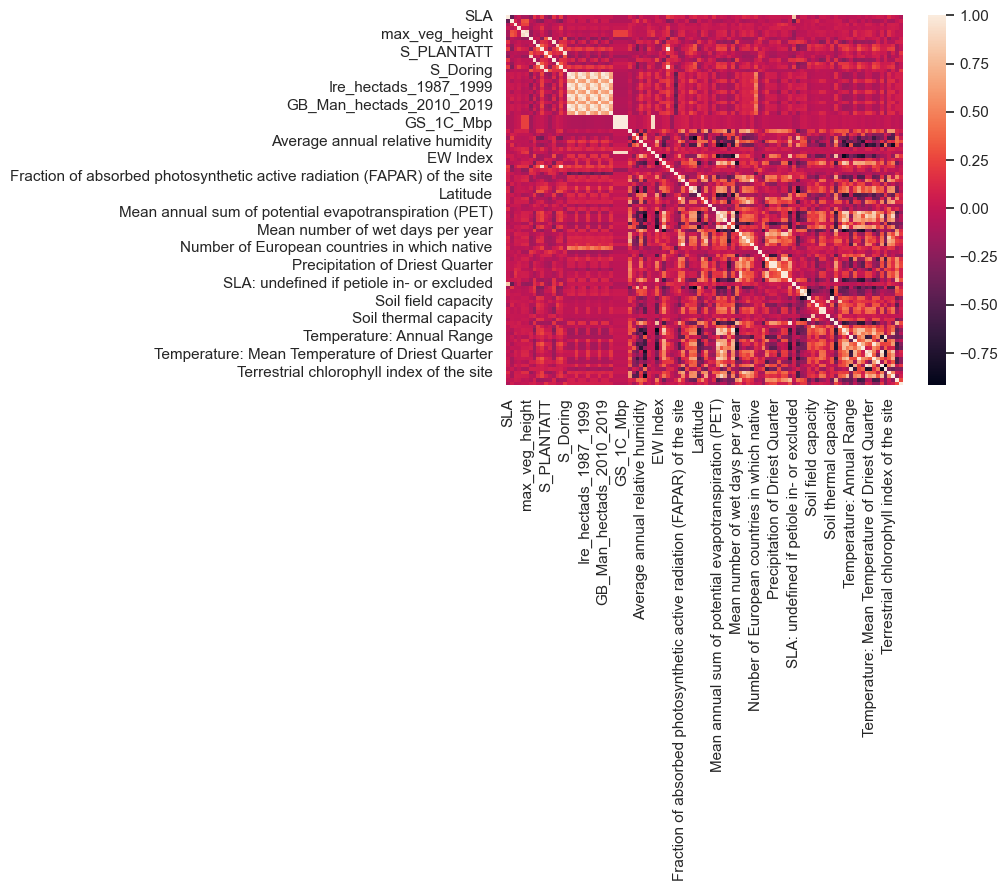

In [83]:
sns.heatmap(corr)

There are clearly patterns here to investigate, However, you needn't limit your self to numeric values and more than 1000 records - you can look at trends seen in trees, compare families of plants, find which traits correlate best with flowering time, with loss of habitat in the twentieth century, or with local rarity.  **Explore!**


### Further reading

Some references which might be useful for ideas:

Brown, M.R., Hollingsworth, P.M., Forrest, L.L., Hart, M.L., Leitch, I.J., Jones, L., Ford, C., De Vere, N. and Twyford, A.D., 2023. Genetic factors predict hybrid formation in the British flora. Proceedings of the National Academy of Sciences, 120(16), p.e2220261120.

Barajas Barbosa, M.P., Craven, D., Weigelt, P. et al. Assembly of functional diversity in an oceanic island flora. Nature 619, 545–550 (2023). https://doi.org/10.1038/s41586-023-06305-z

Lenzner, B., Latombe, G., Schertler, A., Seebens, H., Yang, Q., Winter, M., Weigelt, P., van Kleunen, M., Pyšek, P., Pergl, J. and Kreft, H., 2022. Naturalized alien floras still carry the legacy of European colonialism. Nature Ecology & Evolution, 6(11), pp.1723-1732.

Kent, M., Stevens, R.A. and Zhang, L. (1999), Urban plant ecology patterns and processes: a case study of the flora of the City of Plymouth, Devon, U. K.. Journal of Biogeography, 26: 1281-1298. https://doi.org/10.1046/j.1365-2699.1999.00350.x

Loram, A., Thompson, K., Warren, P.H. and Gaston, K.J. (2008), Urban domestic gardens (XII): The richness and composition of the flora in five UK cities. Journal of Vegetation Science, 19: 321-330. https://doi.org/10.3170/2008-8-18373

Walker, K.J., Preston, C.D. Ecological Predictors of Extinction Risk in the Flora of Lowland England, UK. Biodivers Conserv 15, 1913–1942 (2006). https://doi.org/10.1007/s10531-005-4313-4

Thompson, K., & Ceriani, R. M. (2003). No Relationship between Range Size and Germination Niche Width in the UK Herbaceous Flora. Functional Ecology, 17(3), 335–339. http://www.jstor.org/stable/3599088

Vendramini, F., Díaz, S., Gurvich, D.E., Wilson, P.J., Thompson, K. and Hodgson, J.G. (2002), Leaf traits as indicators of resource-use strategy in floras with succulent species. New Phytologist, 154: 147-157. https://doi.org/10.1046/j.1469-8137.2002.00357.x

Küster, E.C., Kühn, I., Bruelheide, H. and Klotz, S. (2008), Trait interactions help explain plant invasion success in the German flora. Journal of Ecology, 96: 860-868. https://doi.org/10.1111/j.1365-2745.2008.01406.x

Bourgeois, B., Munoz, F., Fried, G., Mahaut, L., Armengot, L., Denelle, P., Storkey, J., et al. 2019. What makes a weed a weed? A large-scale evaluation of arable weeds through a functional lens. American Journal of Botany 106(1): 90–100.
